# Exploring the cryptocurrency market

A snapshot of the cryptocurrency market taken from the coinmarketcap API on 6 December 2017, close to the peak of that year's boom. The questions here are simple: how concentrated is the market, how volatile is it, and how big are most coins really?

Data: `datasets/coinmarketcap_06122017.csv`, one row per coin.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

dec6 = pd.read_csv("datasets/coinmarketcap_06122017.csv", index_col=0)
print(dec6.shape)
dec6.head()

(1326, 15)


,24h_volume_usd,available_supply,id,last_updated,market_cap_usd,max_supply,name,percent_change_1h,percent_change_24h,percent_change_7d,price_btc,price_usd,rank,symbol,total_supply
0,9.007640e+09,1.672352e+07,bitcoin,1512549554,2.130493e+11,2.100000e+07,Bitcoin,0.12,7.33,17.45,1.000000,12739.500000,1,BTC,1.672352e+07
1,1.551330e+09,9.616537e+07,ethereum,1512549553,4.352945e+10,NaN,Ethereum,-0.18,-3.93,-7.33,0.036177,452.652000,2,ETH,9.616537e+07
2,1.111350e+09,1.684044e+07,bitcoin-cash,1512549578,2.529585e+10,2.100000e+07,Bitcoin Cash,1.65,-5.51,-4.75,0.120050,1502.090000,3,BCH,1.684044e+07
3,2.936090e+09,2.779530e+09,iota,1512549571,1.475225e+10,2.779530e+09,IOTA,-2.38,83.35,255.82,0.000424,5.307460,4,MIOTA,2.779530e+09
4,2.315050e+08,3.873915e+10,ripple,1512549541,9.365343e+09,1.000000e+11,Ripple,0.56,-3.70,-14.79,0.000019,0.241754,5,XRP,9.999309e+10


## 1. Coins without a market capitalisation

Some coins have no known market cap, usually because nobody trades them. They are dropped.

In [2]:
market_cap_raw = dec6[["id", "market_cap_usd"]]
print(market_cap_raw.count(), "\n")

cap = market_cap_raw.query("market_cap_usd > 0")
print("Coins with a market cap:", len(cap))

id                1326
market_cap_usd    1031
dtype: int64 

Coins with a market cap: 1031


## 2. How dominant is Bitcoin?

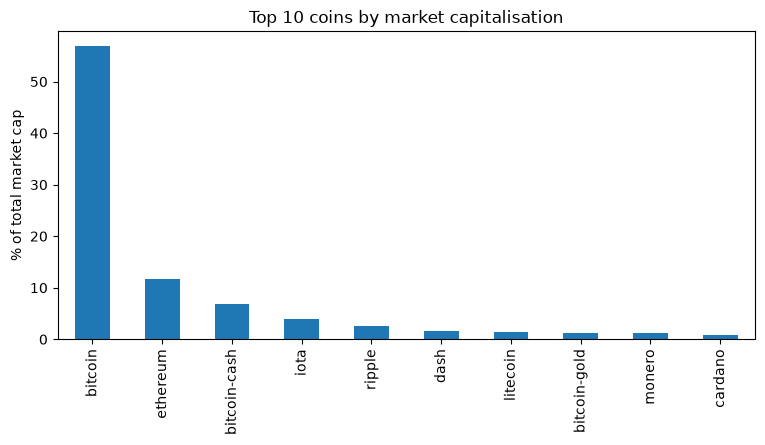

Total market cap: $374 billion


id
bitcoin         56.9
ethereum        11.6
bitcoin-cash     6.8
iota             3.9
ripple           2.5
dash             1.5
litecoin         1.5
bitcoin-gold     1.3
monero           1.2
cardano          0.9
Name: market_cap_perc, dtype: float64

In [3]:
cap10 = cap.nlargest(10, "market_cap_usd").set_index("id")
cap10["market_cap_perc"] = cap10["market_cap_usd"] / cap["market_cap_usd"].sum() * 100

ax = cap10["market_cap_perc"].plot.bar(figsize=(9, 4), title="Top 10 coins by market capitalisation")
ax.set_ylabel("% of total market cap")
ax.set_xlabel("")
plt.show()

print(f"Total market cap: ${cap['market_cap_usd'].sum() / 1e9:.0f} billion")
cap10["market_cap_perc"].round(1)

Bitcoin is so far ahead that the others are hard to compare on a linear scale. The same data in USD on a log scale:

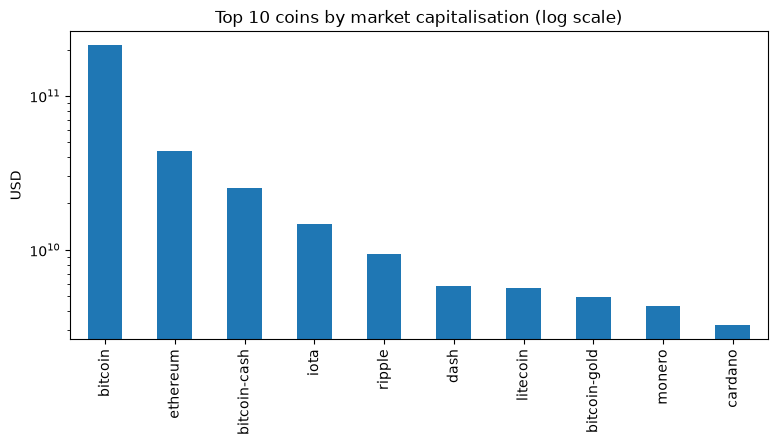

In [4]:
ax = cap10["market_cap_usd"].plot.bar(figsize=(9, 4), logy=True, title="Top 10 coins by market capitalisation (log scale)")
ax.set_ylabel("USD")
ax.set_xlabel("")
plt.show()

## 3. Volatility

Price changes over the previous 24 hours and 7 days.

In [5]:
volatility = dec6[["id", "percent_change_24h", "percent_change_7d"]].set_index("id").dropna()
volatility.describe().round(1)

,percent_change_24h,percent_change_7d
count,1239.0,1239.0
mean,8.7,29.1
std,44.4,120.0
min,-95.8,-99.6
25%,-6.7,-7.9
50%,1.8,11.2
75%,11.9,36.0
max,833.0,3360.7


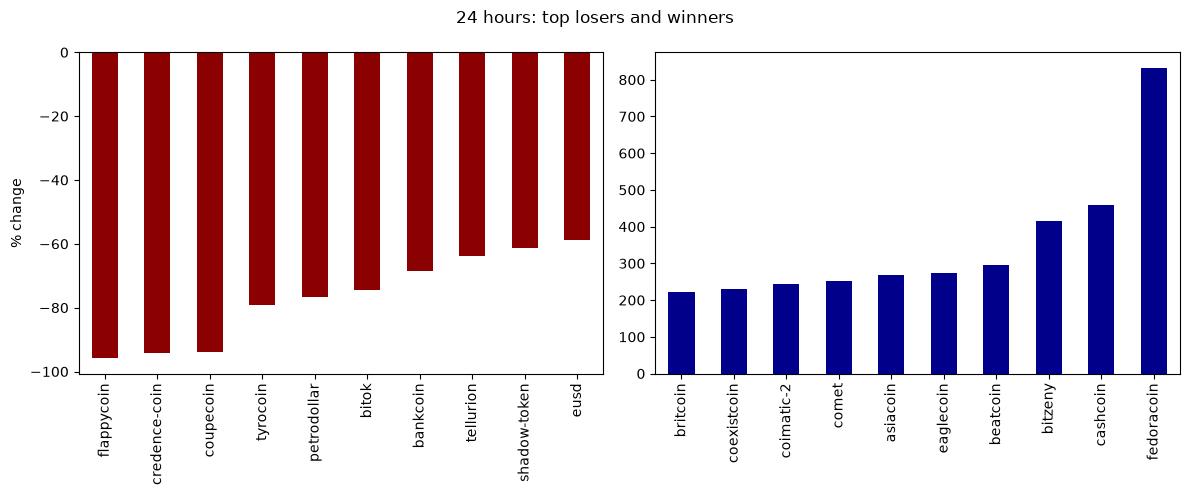

In [6]:
def plot_losers_and_winners(series, title):
    """Bar charts of the ten biggest losers and the ten biggest winners."""
    ordered = series.sort_values()
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ordered.head(10).plot.bar(color="darkred", ax=axes[0])
    ordered.tail(10).plot.bar(color="darkblue", ax=axes[1])
    axes[0].set_ylabel("% change")
    for ax in axes:
        ax.set_xlabel("")
    fig.suptitle(title)
    plt.tight_layout()
    return fig, axes


plot_losers_and_winners(volatility["percent_change_24h"], "24 hours: top losers and winners")
plt.show()

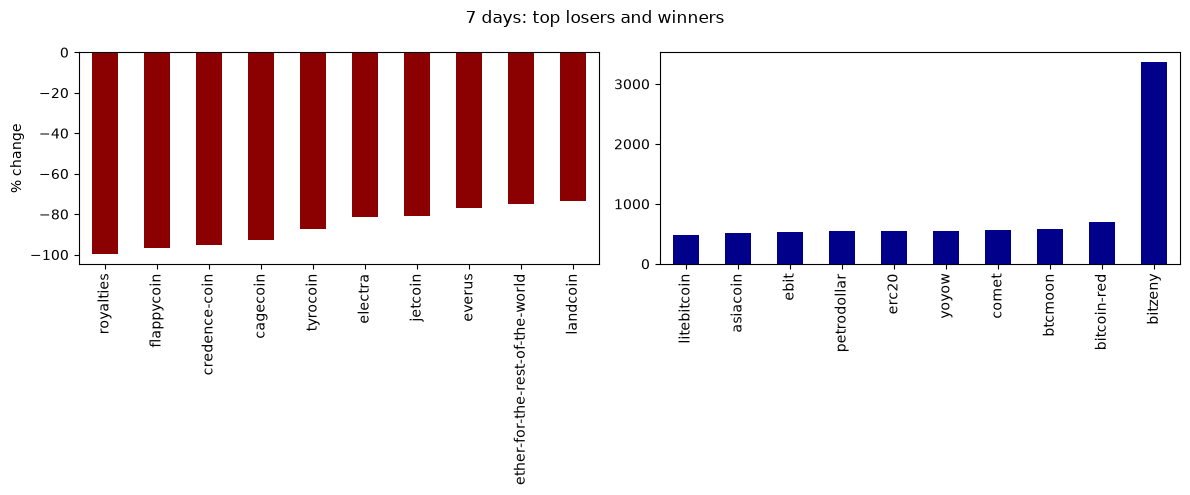

In [7]:
plot_losers_and_winners(volatility["percent_change_7d"], "7 days: top losers and winners")
plt.show()

## 4. Most coins are tiny

The coins with the wildest swings are ones few people have heard of. Grouping by market cap shows how small most of the market is.

In [8]:
cap.query("market_cap_usd > 1e10")

,id,market_cap_usd
0,bitcoin,2.130493e+11
1,ethereum,4.352945e+10
2,bitcoin-cash,2.529585e+10
3,iota,1.475225e+10


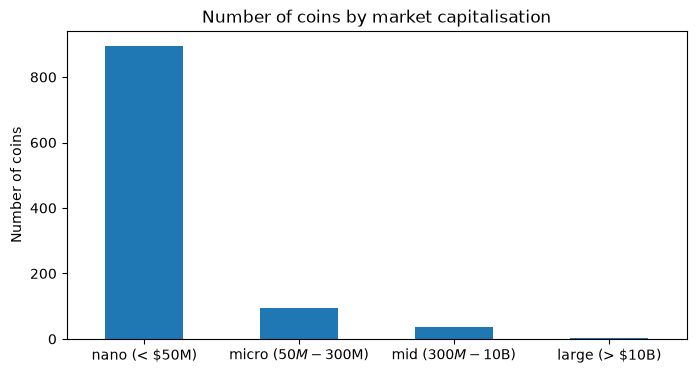

,coins,share_of_coins_pct,share_of_market_cap_pct
market_cap_usd,,,
nano (< $50M),896,86.9,1.4
micro ($50M-$300M),96,9.3,3.1
mid ($300M-$10B),35,3.4,16.2
large (> $10B),4,0.4,79.2


In [9]:
bins = [0, 5e7, 3e8, 1e10, float("inf")]
labels = ["nano (< $50M)", "micro ($50M-$300M)", "mid ($300M-$10B)", "large (> $10B)"]
size_class = pd.cut(cap["market_cap_usd"], bins=bins, labels=labels)

counts = size_class.value_counts().reindex(labels)
ax = counts.plot.bar(figsize=(8, 4), rot=0, title="Number of coins by market capitalisation")
ax.set_ylabel("Number of coins")
ax.set_xlabel("")
plt.show()

summary = pd.DataFrame({
    "coins": counts,
    "share_of_coins_pct": (counts / counts.sum() * 100).round(1),
    "share_of_market_cap_pct": (cap.groupby(size_class, observed=False)["market_cap_usd"].sum() / cap["market_cap_usd"].sum() * 100).round(1),
})
summary

Do small coins move more? Median absolute 24-hour change by size class:

In [10]:
moves = dec6.set_index("id")[["market_cap_usd", "percent_change_24h"]].dropna()
moves = moves[moves["market_cap_usd"] > 0]
moves["size_class"] = pd.cut(moves["market_cap_usd"], bins=bins, labels=labels)
moves.groupby("size_class", observed=False)["percent_change_24h"].agg(
    median_abs_change=lambda s: s.abs().median(), max_gain="max", max_loss="min").round(1)

,median_abs_change,max_gain,max_loss
size_class,,,
nano (< $50M),8.6,457.9,-94.2
micro ($50M-$300M),8.7,833.0,-17.3
mid ($300M-$10B),7.4,110.0,-10.7
large (> $10B),6.4,83.4,-5.5


## Findings

- **Concentration:** of 1,326 listed coins, 1,031 had a market cap, worth $374 billion in total. Bitcoin alone was 57% of that, and the four coins above $10 billion (Bitcoin, Ethereum, Bitcoin Cash, IOTA) made up 79%.
- **Long tail:** 87% of coins were worth less than $50 million each, and together they accounted for 1.4% of the market.
- **Volatility:** the median coin gained 1.8% in a day and 11% in a week, which says a lot about the mood in December 2017. Individual coins moved by as much as +833% and -96% in 24 hours.
- **Size and risk:** a typical daily move is 6-9% in every size class, so even the largest coins were volatile. What changes with size is the extremes: the largest daily loss among coins above $10 billion was 5.5%, against 94% among the smallest.

This is a single day near a market peak, so the numbers describe that moment rather than the market in general.